<a href="https://colab.research.google.com/github/thethien8a/Sentiment-Analysis-Vietnamese/blob/m%E1%BA%A1nh/phoBert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install emoji
# !pip install underthesea
import torch
import requests
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

from underthesea import word_tokenize
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from transformers import TrainingArguments, Trainer
from sklearn.pipeline import Pipeline
from datasets import Dataset, load_metric
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [14]:
# ---- ĐỌC DATA -----
raw_url = 'https://github.com/thethien8a/Sentiment-Analysis-Vietnamese/raw/main/comment_data/Tram_dung_chan_Jack_shuffled.xlsx'
df_cmt = pd.read_excel(raw_url)
df_cmt = df_cmt[['textDisplay', 'label']]
df_cmt.head()

,textDisplay,label
0,Đừng dối lòng phủ nhận tài năng của Jack. Nhìn...,2.0
1,mình là tài xế chạy grab gần 8 năm chưa bao gi...,2.0
2,Sky qua ủng hộ Jack \nChúc dự án này thành côn...,2.0
3,"Không uổn công tui cày từ 5 giờ sáng tới giờ, ...",2.0
4,Đa số nghệ sĩ trong showbiz hiện giờ á toàn qu...,2.0


## Tạo từ điển viết tắt và Tạo hàm

In [3]:
TEENCODE_DICT = {
    'ko': 'không', 'k': 'không', 'kh': 'không', 'bt': 'biết',
    'dc': 'được', 'đc': 'được', "ak":"à", "àh":"à",
    "uk":"ừ","uh":"ừ", "cmnl":"con mẹ nó luôn",
    'ad': 'admin', 'ntn': 'như thế nào',
    'v': 'vậy', 'r': 'rồi', "qtr":"quá trời",
    'cx': 'cũng',
    'ib': 'inbox',
    'rep': 'trả lời',
    'mn': 'mọi người',
    'cmt': 'comment',
    'b': 'bạn',
    "tr":"trời",
    'e': 'em',
    'a': 'anh',
    "ng":"người", "lm":"làm", "cầu đặc": "đầu cặc", "kẹc":"cặc", "đ":"đéo", "gđ":"gia đình", "cằk":"cặc","cặk":"cặc", 'okela':'ok', "djt":"địt",
    "trây":"jack",  "bn":"bao nhiêu","bnh":"bao nhiêu", "cmm":"con mẹ","cm":"chúng mày","clm":"cái lồn má", 'vc':'vãi cả', 'cc':'cục cứt', 'loz':'lồn', 'l':'lồn', "lol":"lồn","lòn":"lồn", "lôn":"lồn",
    'vl':'vãi lồn',"vcl":"vãi cả lồn","vkl":"vãi cả lồn", "đcm":"địt con mẹ","đm":"địt mẹ","đcmm":"địt con mẹ","đcmmm":"địt con mẹ", "đb":"đầu buồi",
    'deo':'đéo','dell':'đéo', 'vcc':"vãi cả cứt", "occho":"óc chó", "t":"tôi", "chx":"chưa", "xg":"xong",
    "vcd":"vãi cả đái","vcđ":"vãi cả đái",
    "ae":"anh em", "j":"gì",
    "soll":"son","sol":"son",
    "vaiz":"vãi",
    "mn":"mọi người","mng":"mọi người",
    "bth":"bình thường",
    "m":"mày",
    "cm":"chúng mày",
    "ch":"chưa",
    "vs":"với",
    "sv":"súc vật",
    "c":"cứt",
    "t.o.p":"top",
    "ncc":"như cục cứt",
    "dit":"địt","djt":"địt",
    "hth":"hiếu thứ hai",
    "qc":"quảng cáo",
    "vn":"việt nam", "vaiz":"vãi",
    "r":"rồi", "nge":"nghe", "tiktok":"tik tok", "ytb":"youtube", "fb":"facebook", "vcut":"vãi cứt","shit":"cứt", "fl":"follow"
}

EMOJI_DICT = {
    "😢":" bieu_tuong_buon ",
    "🎉":" bieu_tuong_chuc_mung ",
    "❤":" bieu_tuong_trai_tim ",
    "🤣":" bieu_tuong_mat_cuoi ", "😂":" bieu_tuong_mat_cuoi ",
    "😭":" bieu_tuong_khoc ",
    "🔥":" bieu_tuong_chay ",
    "💩":" bieu_tuong_cut ",
    "🥰":" bieu_tuong_yeu_thuong ",
    "😮":" bieu_tuong_ngac_nhien ",
    "😅":" bieu_tuong_lo_lang ",
    "<3":" bieu_tuong_trai_tim "
}

STOP_WORDS = set()

raw_url = 'https://github.com/thethien8a/Sentiment-Analysis-Vietnamese/raw/main/vietnamese-stopwords-dash.txt'
response = requests.get(raw_url)
# Kiểm tra xem yêu cầu có thành công không (status code 200 là OK)
if response.status_code == 200:
    lines = response.text.splitlines()
    for line in lines:
        word = line.strip()
        if word:
            STOP_WORDS.add(word)
        else:
          break
    print(f"Tải xong {len(STOP_WORDS)} STOP_WORDS")

Tải xong 1942 STOP_WORDS


In [4]:
def preprocessing_basic(text):
  text = text.lower()
  text = re.sub(r'http\S+','',text)
  text = re.sub(r'<.*?>', '', text)
  text = text.strip()
  text = text.replace("t o p","top").replace("tốp","top")
  text = text.replace("v i e w","view").replace("c à y","cày")
  text = text.replace("đốn lòm","đóm lồn").replace("đốm lòn","đóm lồn")
  return text

def replace_teencode(text,teencode_dict):
  words = text.split()
  for idx,each_word in enumerate(words):
    if each_word in teencode_dict:
      words[idx] = teencode_dict[each_word]
  return ' '.join(words)

def exception_stop_words(text):
  return text.replace("hay","hayy")

def replace_emoji(text,emoji_dict):
  for emoji, word in emoji_dict.items():
      text = text.replace(emoji, word)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

def remove_stop_words(text,stop_words):
  words = text.split()
  filtered_words = [word for word in words if word not in STOP_WORDS]
  return ' '.join(filtered_words)


def keep_chars(text):
  vietnamese_chars = 'àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ'
  # Whitelist bao gồm: chữ cái a-z, chữ cái tiếng Việt, và dấu gạch dưới
  allowed_chars = vietnamese_chars + 'a-z_'
  # Tạo pattern để tìm các ký tự KHÔNG thuộc whitelist (và cũng không phải khoảng trắng)
  unwanted_chars_pattern = re.compile(f'[^{allowed_chars}\s]')
  text = unwanted_chars_pattern.sub('', text)
  text = re.sub(r'\s+',' ',text)
  text = text.strip()
  return text

def compute_metrics(eval_pred):
   load_accuracy = load_metric("accuracy")
   load_f1 = load_metric("f1")

   logits, labels = eval_pred
   predictions = np.argmax(logits, axis=-1)
   accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
   f1 = load_f1.compute(predictions=predictions, references=labels)["f1"]
   return {"accuracy": accuracy, "f1": f1}


def preprocess_comment(text):
    global TEENCODE_DICT
    global EMOJI_DICT
    global STOP_WORDS

    text = preprocessing_basic(text)
    text = replace_teencode(text, TEENCODE_DICT)
    text = replace_emoji(text,EMOJI_DICT)
    text = keep_chars(text)

    # Tách từ cho có nghĩa
    text = word_tokenize(text, format="text")
    text = exception_stop_words(text)
    text = remove_stop_words(text,STOP_WORDS)
    return text

## Tiền xử lý

In [15]:
# Xoá NaN
df_cmt = df_cmt.dropna()
# Lọc trùng bình luận (tránh seeding)
df_cmt = df_cmt.drop_duplicates(subset=['textDisplay'], keep='first')
df_cmt['label'] = df_cmt['label'].astype(int)
df_cmt["textDisplay"] = df_cmt["textDisplay"].fillna("").apply(preprocess_comment)

In [18]:
df_cmt

,textDisplay,label
0,hoài chán,2
1,hayyyy,2
2,cover hayy,2
3,đom đóm bieu_tuong_trai_tim bieu_tuong_trai_tim,2
4,ca khúc trữ_tình tuyệt_đỉnh,2
...,...,...
895,trò bá_dơ rác mxh,0
896,truyền_thông bẩn mv_nhục,0
897,súc sinh,0
898,nhạc lồn,0


In [17]:
# Thử với 900 comment 0<POS<2000; 2220<NEU<3000; 3300<NEG)
df_cmt = pd.concat([
    df_cmt.iloc[1000:1300],
    df_cmt.iloc[2220:2520],
    df_cmt.iloc[3300:3600]
]).reset_index(drop=True)

# Shuffle
# df_cmt = df_cmt.sample(frac=1, random_state = 42).reset_index(drop=True)
# df_cmt.head(10)

In [19]:
# --- BƯỚC 2: TIỀN XỬ LÝ VÀ TOKENIZATION ---
# Chuyển DataFrame thành đối tượng Dataset của Hugging Face
hg_cmt = Dataset.from_pandas(df_cmt)

model_name = "wonrax/phobert-base-vietnamese-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Định nghĩa hàm tiền xử lý
def preprocess_function(examples):
    return tokenizer(examples["textDisplay"], truncation=True, padding="max_length")

# Áp dụng hàm preprocess_function bằng .map()
tokenized_dataset = hg_cmt.map(preprocess_function, batched=True)

# Dọn dẹp các cột không cần thiết
# Mô hình chỉ cần 'input_ids', 'attention_mask', và 'label_id' (sẽ được đổi tên thành 'labels')
# tokenized_dataset = tokenized_dataset.remove_columns(['textDisplay', 'label'])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# --- BƯỚC 3: KIỂM TRA KẾT QUẢ ---
print("\nDataset đã được xử lý và sẵn sàng để huấn luyện:")
print(tokenized_dataset)
print("\nXem thử một mẫu đầu tiên:")
print(tokenized_dataset[0])

Map:   0%|          | 0/900 [00:00<?, ? examples/s]


Dataset đã được xử lý và sẵn sàng để huấn luyện:
Dataset({
    features: ['textDisplay', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 900
})

Xem thử một mẫu đầu tiên:
{'textDisplay': 'hoài chán', 'labels': 2, 'input_ids': [0, 9903, 5015, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## Huấn luyện

In [20]:
# --- CHIA DỮ LIỆU ---
train_test_split = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test_split['train']
test_dataset = train_test_split['test']

print("Dataset gốc đã được tokenize:", tokenized_dataset)
print("\nKết quả sau khi chia:")
print(train_test_split)

# Xem thử một mẫu để chắc chắn cấu trúc vẫn đúng
print("\nMột mẫu trong tập train:")
print(train_dataset['labels'])

Dataset gốc đã được tokenize: Dataset({
    features: ['textDisplay', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 900
})

Kết quả sau khi chia:
DatasetDict({
    train: Dataset({
        features: ['textDisplay', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 720
    })
    test: Dataset({
        features: ['textDisplay', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 180
    })
})

Một mẫu trong tập train:
[1, 0, 1, 1, 2, 2, 0, 1, 0, 1, 1, 0, 0, 2, 1, 0, 0, 1, 1, 2, 2, 2, 1, 2, 0, 1, 2, 2, 2, 1, 0, 0, 2, 0, 1, 1, 0, 1, 2, 0, 2, 0, 1, 1, 1, 0, 2, 1, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 1, 0, 0, 0, 2, 0, 0, 2, 2, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 1, 1, 1, 0, 2, 0, 2, 1, 2, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 1, 2, 0, 2, 1, 1, 0, 0, 2, 2, 2, 1, 1, 2, 0, 2, 1, 1, 0, 1, 0, 2, 0, 1, 1, 1, 2, 0, 1, 0, 0, 1, 0, 2, 0, 2, 2, 2, 1, 2, 2, 0, 0, 1, 1, 

In [21]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [22]:
# ---- LOAD MODEL ----
label2id = {'NEG': 0, 'NEU': 1, 'POS': 2}
id2label = {0: 'NEG', 1: 'NEU', 2:'POS'}

model = AutoModelForSequenceClassification.from_pretrained(
  model_name,
  num_labels=3,
  id2label=id2label,
  label2id=label2id
)

In [23]:
# ---- BẮT ĐẦU HUẤN LUYỆN ----
local_output_dir = "./phobert_local_finetuned_results"

training_args = TrainingArguments(
    output_dir=local_output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none",   # Nếu xoá dòng này đi thì phải lên hugging face lấy api key
    save_strategy="epoch",
    # push_to_hub=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [24]:
trainer.train()

Step,Training Loss


TrainOutput(global_step=135, training_loss=0.9308818110713253, metrics={'train_runtime': 142.0694, 'train_samples_per_second': 15.204, 'train_steps_per_second': 0.95, 'total_flos': 284162491146240.0, 'train_loss': 0.9308818110713253, 'epoch': 3.0})

In [25]:
trainer.save_model(local_output_dir) # Nếu lưu trên VM của colab
# trainer.push_to_hub() # Lưu trên hub hugging face

## Dự đoán

In [26]:
# Tải model đã fine-tune vào pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=local_output_dir)

Device set to use cuda:0


In [38]:
# --- CHUYỂN TOÀN BỘ DATASET SANG PANDAS DATAFRAME ---
df_test = test_dataset.to_pandas()
df_test = df_test[['textDisplay', 'labels']]
df_test['labels_tag'] = df_test['labels'].map(id2label)
df_test.head()

# Chuyển comment thành list
comment_list = df_test['textDisplay'].tolist()
comment_list[:5]

['tóp',
 'tác_giả hát bùng_nổ',
 'bieu_tuong_trai_tim mê',
 'mãi yêu jack',
 'hẹ hẹ hẹ bieu_tuong_mat_cuoi bieu_tuong_mat_cuoi bieu_tuong_mat_cuoi bieu_tuong_mat_cuoi']

In [39]:
# --- TIẾN HÀNH DỰ ĐOÁN ---
results = sentiment_analyzer(comment_list)

labels = [result['label'] for result in results]
scores = [result['score'] for result in results]
results[:5]

df_test['sentiment_label'] = labels
df_test['sentiment_score'] = scores

In [42]:
df_test.iloc[:,:]

,textDisplay,labels,labels_tag,sentiment_label,sentiment_score
0,tóp,1,NEU,NEU,0.527611
1,tác_giả hát bùng_nổ,2,POS,POS,0.574408
2,bieu_tuong_trai_tim mê,2,POS,POS,0.506299
3,mãi yêu jack,2,POS,POS,0.502312
4,hẹ hẹ hẹ bieu_tuong_mat_cuoi bieu_tuong_mat_cu...,1,NEU,NEG,0.849330
...,...,...,...,...,...
175,trạm dừng chân jack đạo hát ele yan nhan_nhân ...,0,NEG,NEG,0.915279
176,tồn_tại nghệ_sĩ,0,NEG,NEU,0.505702
177,chép take my heart hả,0,NEG,NEG,0.958228
178,đụng pl đổi giọng liền xóa xl đồ quên đi miss_tầm,0,NEG,NEG,0.929998


## ĐÁNH GIÁ KẾT QUẢ

ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH
Accuracy (Độ chính xác tổng thể): 57.22%

Classification Report:

              precision    recall  f1-score   support

         NEG       0.64      0.80      0.71        54
         NEU       0.39      0.44      0.41        54
         POS       0.71      0.50      0.59        72

    accuracy                           0.57       180
   macro avg       0.58      0.58      0.57       180
weighted avg       0.59      0.57      0.57       180


Confusion Matrix:


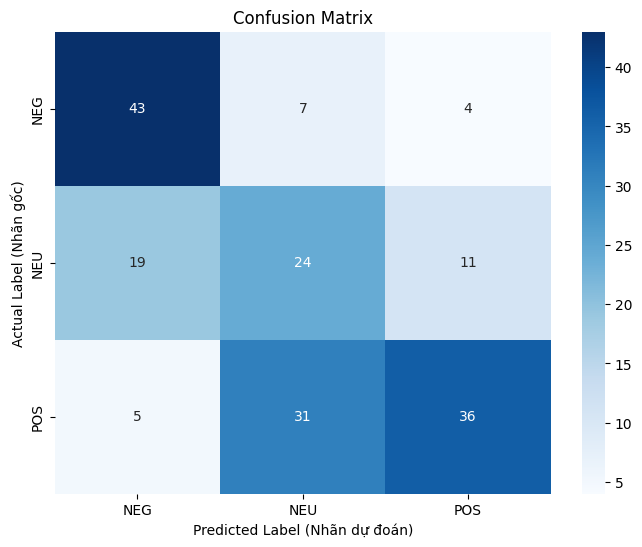

In [45]:
y_true = df_test['labels_tag']
y_pred = df_test['sentiment_label']

# Xác định tất cả các nhãn có thể có để đảm bảo thứ tự nhất quán
class_names = ['NEG', 'NEU', 'POS']

# --- BƯỚC 2: TÍNH TOÁN VÀ IN CÁC CHỈ SỐ ---
print("ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH\n" + "="*30)

# 2.1. Độ chính xác tổng thể (Accuracy)
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy (Độ chính xác tổng thể): {accuracy:.2%}\n")

# 2.2. Báo cáo phân loại chi tiết (Classification Report)
print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# --- BƯỚC 3: VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label (Nhãn gốc)')
plt.xlabel('Predicted Label (Nhãn dự đoán)')
plt.show()

In [48]:
# --- BƯỚC 4 (TÙY CHỌN): XEM LẠI CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI ---
print("\nCÁC TRƯỜNG HỢP DỰ ĐOÁN SAI:\n" + "="*30)
misclassified = df_test[df_test['labels_tag'] != df_test['sentiment_label']]
print(misclassified[['textDisplay', 'labels_tag', 'sentiment_label']])


CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI:
                                           textDisplay labels_tag  \
4    hẹ hẹ hẹ bieu_tuong_mat_cuoi bieu_tuong_mat_cu...        NEU   
6                             cảm_giác mik hợp like kk        NEU   
7                                               ủng_hộ        POS   
10                                live o dau vay ha ha        NEU   
12       phốt ca_sĩ đài_loan hẹ hẹ bieu_tuong_mat_cuoi        NEU   
..                                                 ...        ...   
154                                        thấm nghiện        POS   
159  xuất_sắc lắng_nghe câu chữ giai_điệu cuốn_hút ...        POS   
164                                           nhe_nhạc        POS   
172                              hú hú húuuuu hayyyyyy        POS   
176                                    tồn_tại nghệ_sĩ        NEG   

    sentiment_label  
4               NEG  
6               POS  
7               NEU  
10              NEG  
12              NEG  
..        